In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform

In [60]:
import pickle
import joblib

In [48]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [3]:
names = ['CRIM','ZN','INDUS','CHAS','NOX','RM',
        'AGE','DIS','RAD','TAX', 'PTRATTO','B','LSTAT','MEDV']

In [4]:
df = pd.read_csv('housing.csv', sep = '\s+', names = names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATTO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATTO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


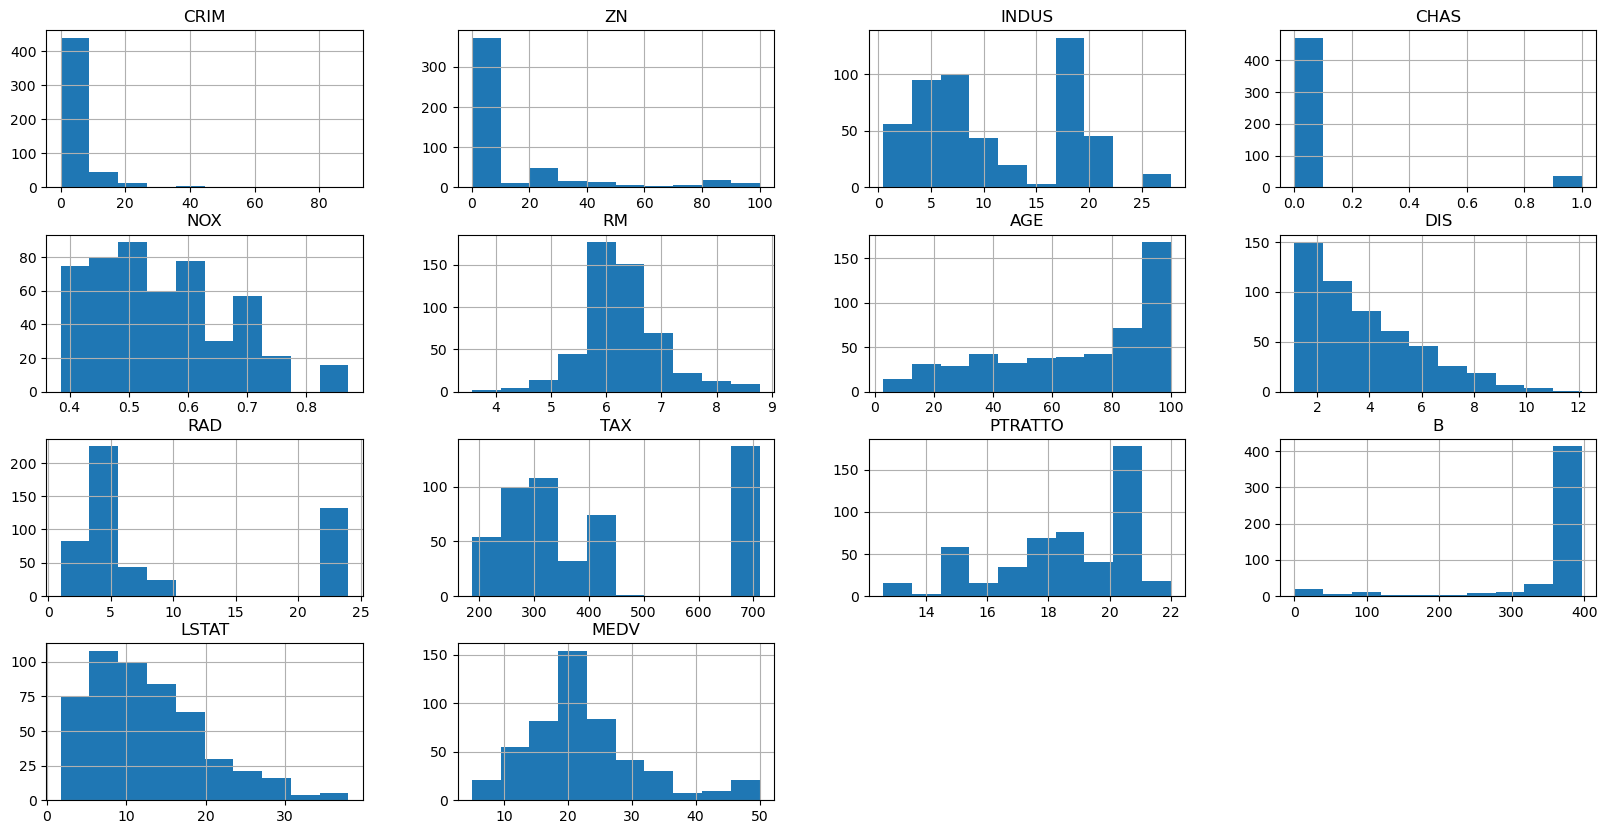

In [7]:
df.hist(figsize = (20,10));

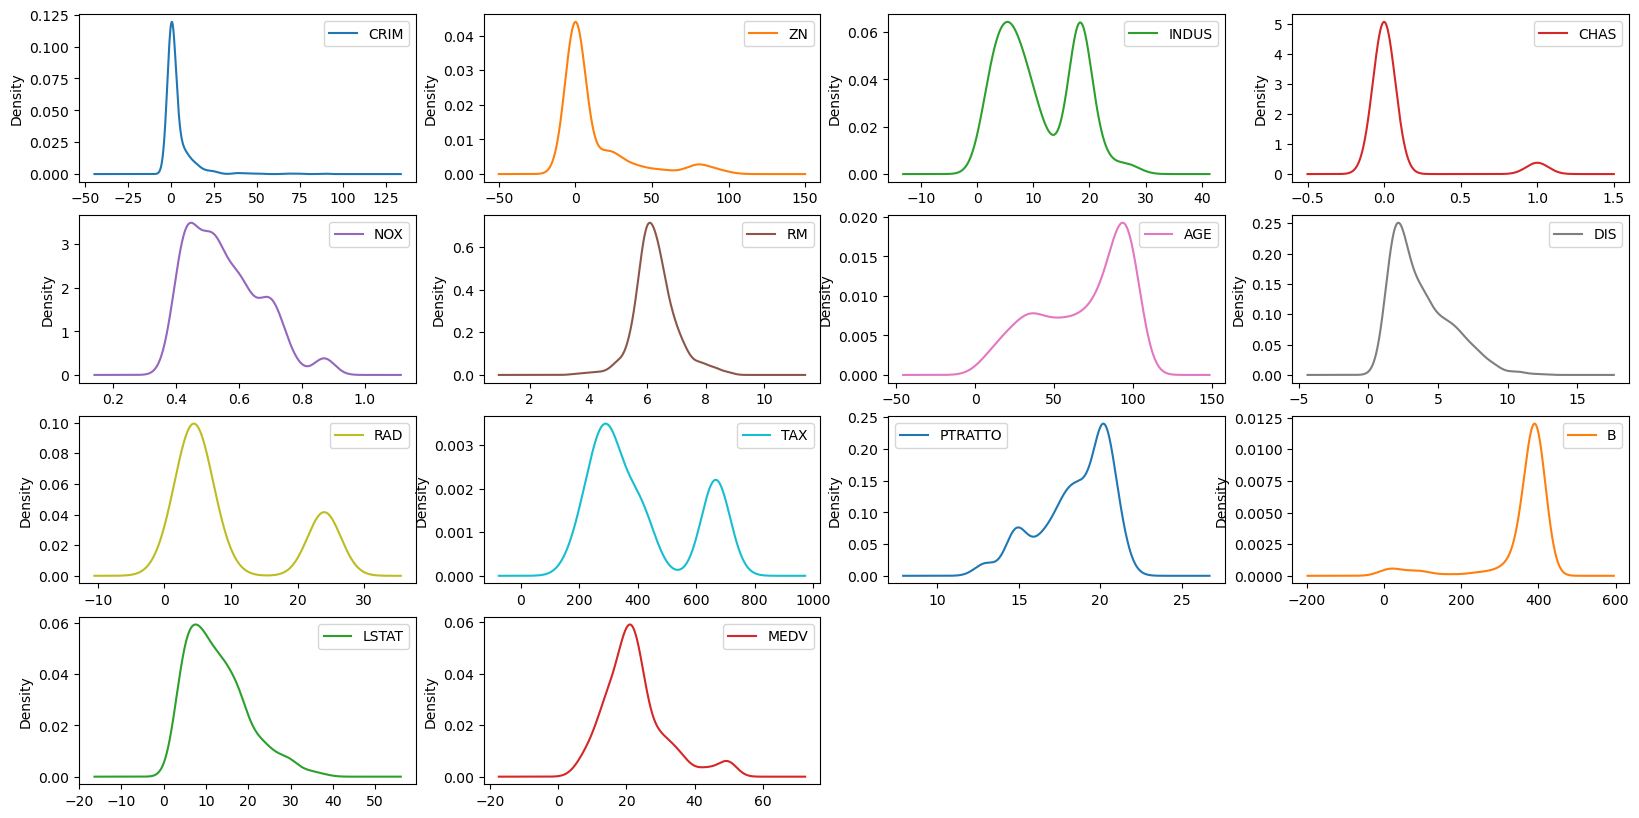

In [8]:
df.plot(kind= 'kde', subplots = True, layout = (4,4), sharex = False, figsize = (20,10));

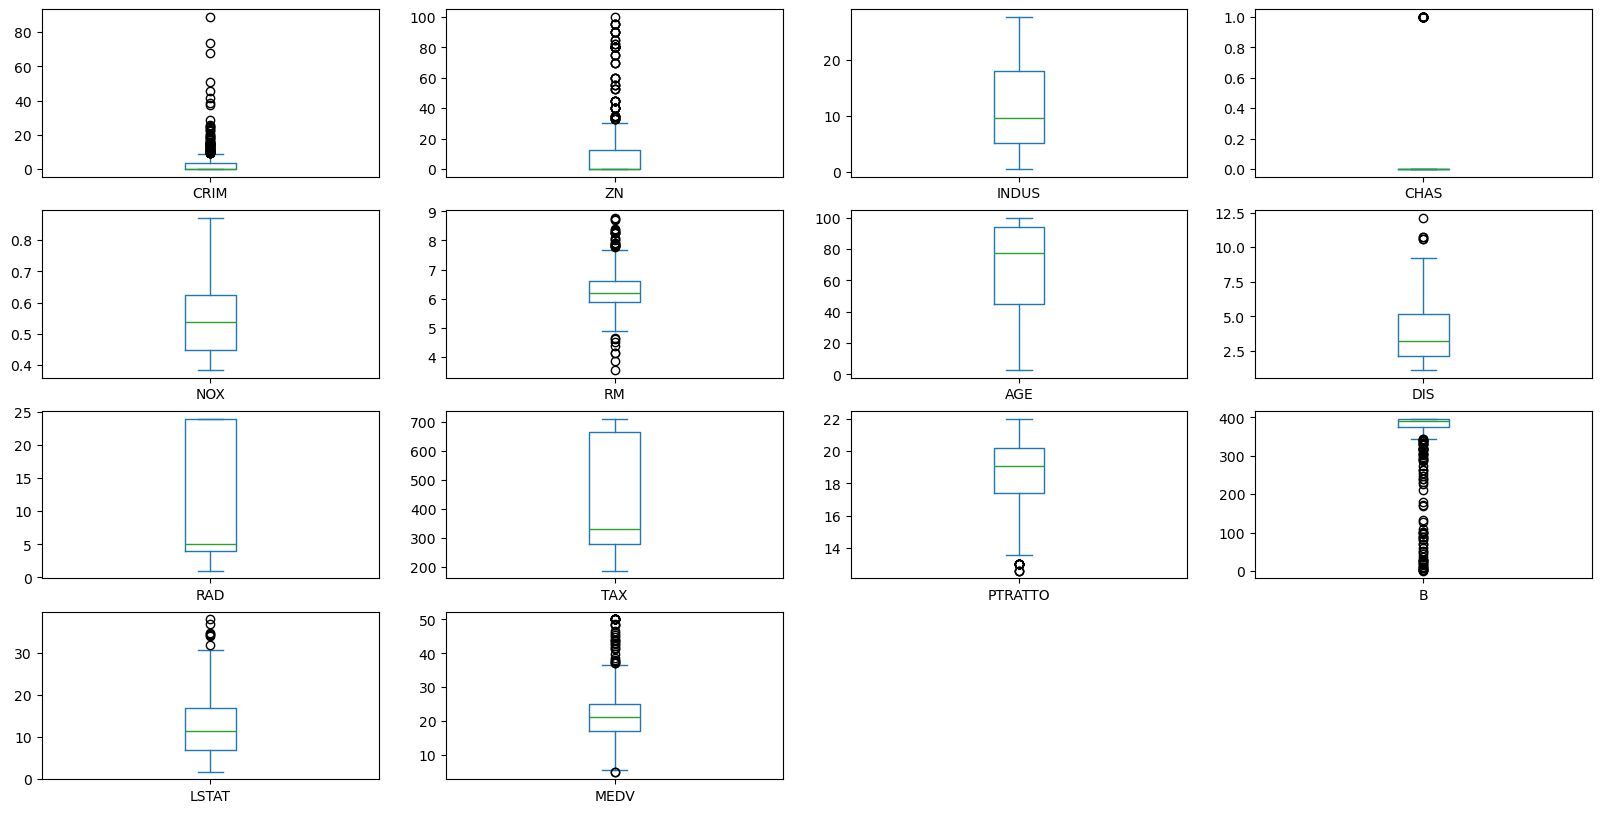

In [9]:
df.plot (kind = 'box', subplots = True, layout = (4,4), sharex = False, figsize = (20,10));

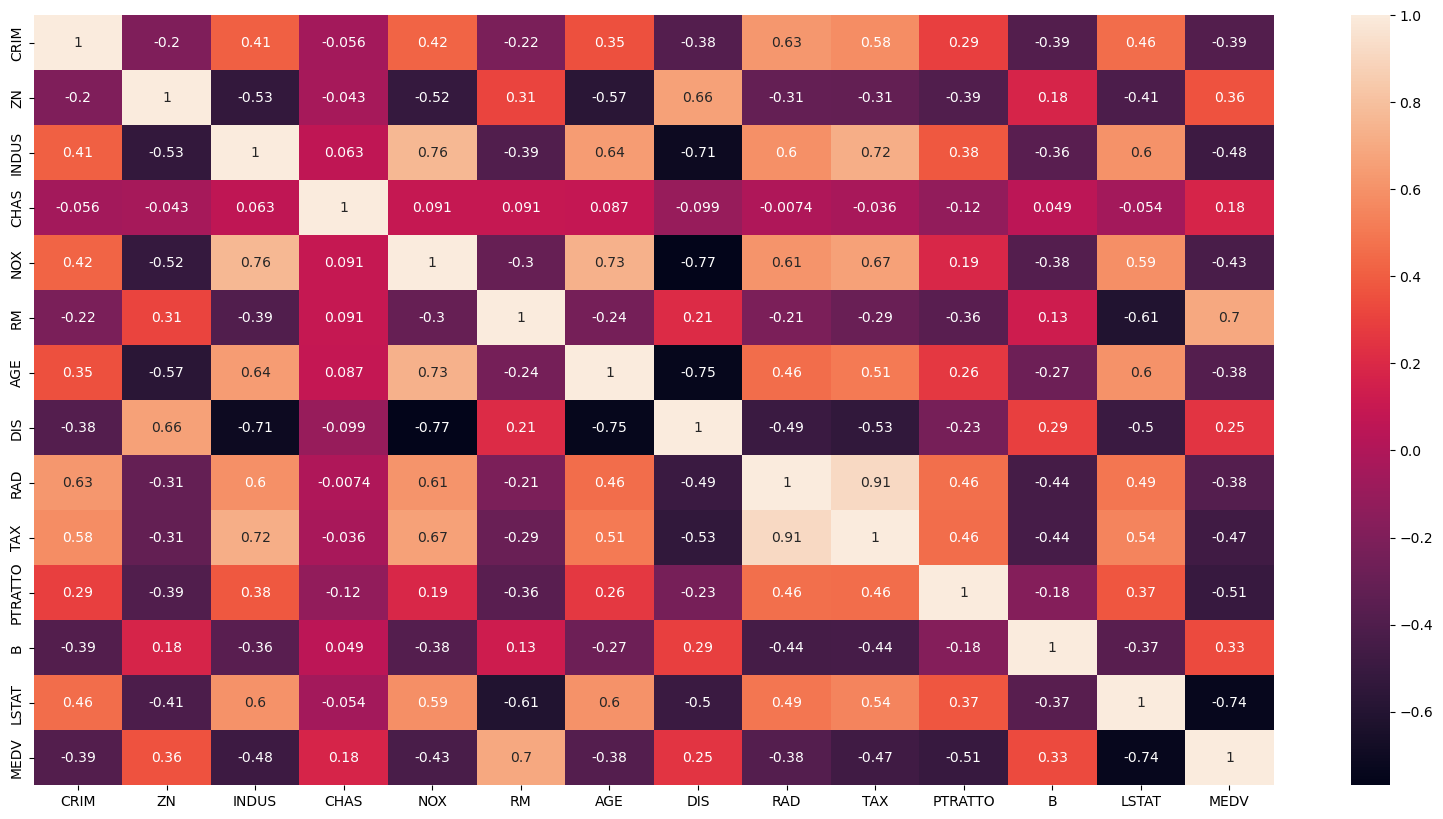

In [10]:
fig, ax = plt.subplots(figsize = (20,10))
sns.heatmap (df.corr(),annot = True);

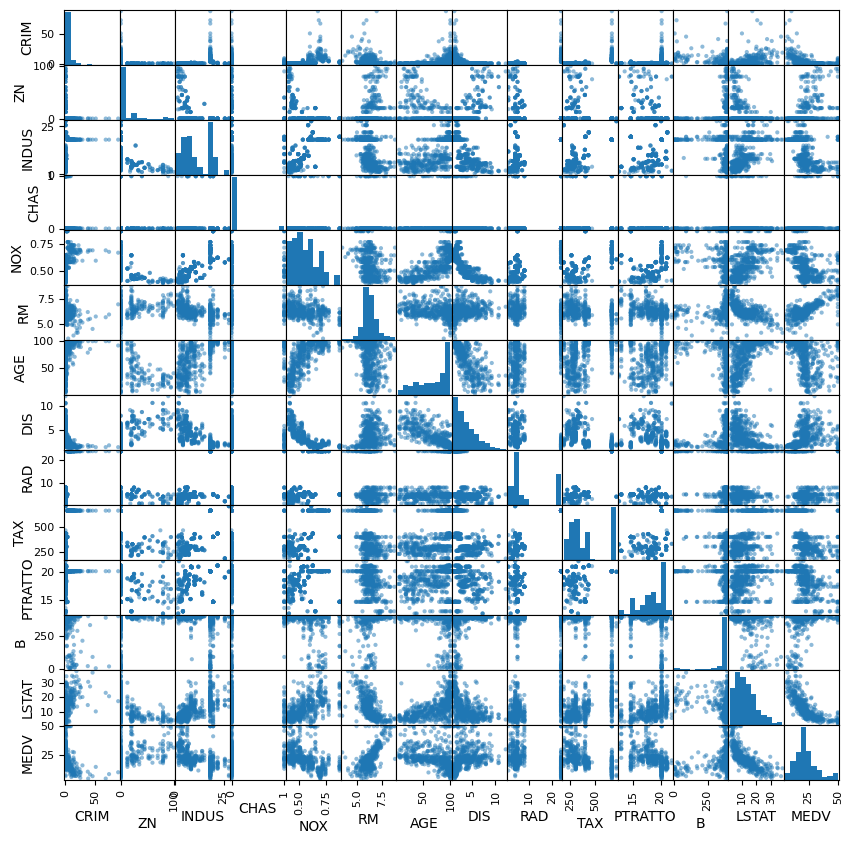

In [11]:
pd.plotting.scatter_matrix(df, figsize=(10,10));

In [12]:
array = df.values
X = array[:,:13]
y = array[:,13]

In [13]:
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 17)

In [14]:
lr = LinearRegression().fit(X_train,y_train)
lr_pred = lr.predict(X_test)
mean_squared_error(y_test,lr_pred)

19.81351684030057

In [15]:
def outlet (x:array):
    lq = x.quantile (0.25)
    uq = x.quantile (0.75)
    iqr = uq-lq
    lb = lq-1.5*iqr
    ub = uq+1.5*iqr
    col = (x<=lb)|(x>=ub)
    print(sum(col))
    return col

In [16]:
out = outlet(df['CRIM'])

66


In [17]:
df = df.drop(df[out].index)
df.shape

(440, 14)

In [18]:
array = df.values
X = array[:,:13]
y = array[:,13]
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 17)

In [19]:
lr = LinearRegression().fit(X_train,y_train)
lr_pred = lr.predict(X_test)
mean_squared_error(y_test,lr_pred)

12.830104150776725

In [20]:
out = outlet(df['MEDV'])

31


In [21]:
df = df.drop(df[out].index)
df.shape

(409, 14)

In [22]:
array = df.values
X = array[:,:13]
y = array[:,13]
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 17)

In [23]:
lr = LinearRegression().fit(X_train,y_train)
lr_pred = lr.predict(X_test)
mean_squared_error(y_test,lr_pred)

9.520636936019717

In [24]:
alphas = np.round(np.linspace(0,1,num = 10), 1).tolist()
alphas

[0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]

In [25]:
param_grid = dict(alpha = alphas)
param_grid

{'alpha': [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]}

In [26]:
ridge_model = Ridge()

In [27]:
grid = GridSearchCV(estimator = ridge_model, param_grid = param_grid)
grid.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.0, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1.0


In [28]:
grid.best_estimator_.alpha

1.0

In [29]:
grid.best_score_

0.7207449511421508

In [30]:
ridge = Ridge(alpha = grid.best_estimator_.alpha).fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)
mean_squared_error (y_test,ridge_pred)

9.554975440191226

In [31]:
np.sqrt(mean_squared_error (y_test,ridge_pred))

3.091112330568274

Случайный поиск по сетке

In [36]:
param_grid = {'alpha': uniform()}

In [38]:
model = Ridge()

In [39]:
rsearch = RandomizedSearchCV(estimator = model, param_distributions = param_grid,
                            n_iter = 100, random_state=7)

In [40]:
rsearch.fit(X_train, y_train)

,estimator,Ridge()
,param_distributions,{'alpha': <scipy.stats....x7355039a29f0>}
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,7
,error_score,nan


In [42]:
rsearch.best_estimator_.alpha

0.9779895119966027

In [43]:
model = Ridge(alpha = rsearch.best_estimator_.alpha)

In [44]:
model.fit(X_train, y_train)
model_pred = model.predict(X_test)
mean_squared_error(y_test, model_pred)

9.554123407817137

In [45]:
models=[]

In [49]:
models.append(('LinRegr', LinearRegression()))
models.append(('Ridge', Ridge(alpha=grid.best_estimator_.alpha)))
models.append(('Lasso', Lasso()))
models.append(('ElasticNet', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('cart', DecisionTreeRegressor()))

In [51]:
results = []
names = []

In [52]:
for name,model in models:
    fitted = model.fit(X_train,y_train)
    y_pred = fitted.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    results.append(mse)
    names.append(name)
    print(f'{name}:{mse}')

LinRegr:9.520636936019717
Ridge:9.554975440191226
Lasso:15.211526032399073
ElasticNet:13.808867805832598
KNN:18.204575609756102
cart:12.170731707317074


In [53]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
model.coef_

array([-0.80567374,  0.04011472, -0.02485995, -0.13669628, -4.58883413,
        3.64558445, -0.03079268, -1.01981064,  0.38099433, -0.01302424,
       -0.59633526,  0.00766207, -0.29098976])

In [55]:
y_pred = model.predict(X_test)
mean_squared_error(y_test,y_pred)

9.520636936019717

In [57]:
new_data = np.array([0.07632, 20.0, 9.35, 0,0.540,7.189, 63.1,
                    5.0900,3.0,298.0,17.5,393.0,5.97]).reshape(1,-1)

In [59]:
model.predict(new_data)

array([27.62092665])

Сохранение весов

In [61]:
pickle.dump(model,open('weights.sav','wb'))

In [62]:
loaded_model = pickle.load(open('weights.sav','rb'))

In [63]:
loaded_model.coef_

array([-0.80567374,  0.04011472, -0.02485995, -0.13669628, -4.58883413,
        3.64558445, -0.03079268, -1.01981064,  0.38099433, -0.01302424,
       -0.59633526,  0.00766207, -0.29098976])

In [64]:
y_pred = loaded_model.predict(X_test)
mean_squared_error(y_test,y_pred)

9.520636936019717

In [65]:
joblib.dump(model,'weights_new.sav')

['weights_new.sav']

In [66]:
loaded_model_new = joblib.load('weights_new.sav')

In [67]:
y_pred = loaded_model_new.predict(X_test)
mean_squared_error(y_test,y_pred)

9.520636936019717